# generating embeddings with model trained with cls-pooling vs Xpressor layers


In [40]:
! uv pip list | grep gseap

Using Python 3.11.11 environment at: /pasteur/appa/homes/jkalfon/scPRINT/.venv
gseapy                                    1.1.11


In [1]:
#! lamin init --storage ./lamin-intro --schema bionty

import scanpy as sc
from scprint2 import scPRINT2
from scprint2.tasks import GeneEmbeddingExtractor
from scdataloader import Preprocessor
from scdataloader.utils import load_genes
import numpy as np
import anndata as ad
from huggingface_hub import hf_hub_download

from scipy.stats import spearmanr
from anndata import AnnData

from grnndata.utils import TF, file_dir
import gseapy as gp

import os
import urllib.request

%load_ext autoreload
%autoreload 2

import torch

torch.set_float32_matmul_precision("medium")

→ connected lamindb: jkobject/scprint2


In [2]:
LOC = "/pasteur/appa/scratch/jkalfon/data/spcrint_data/"  # "../..data/"  #

adata = sc.read(
    LOC + "temp/glio_smart_highdepth" + ".h5ad",
    backup_url="https://datasets.cellxgene.cziscience.com/6ec440b4-542a-4022-ac01-56f812e25593.h5ad",
)

max_len = 4000 if adata.X.sum(1).mean() < 10_000 else 8000
preprocessor = Preprocessor(
    force_preprocess=True,
    skip_validate=True,
    # drop_non_primary=False,
    do_postp=True,
)
print("")
print(adata.X.sum(1).mean())
adata = preprocessor(adata)


388362.5
Dropping layers:  KeysView(Layers with keys: )
checking raw counts
removed 0 non primary cells, 3589 renamining
filtered out 22 cells, 3567 renamining
Removed 0 genes not known to the ontology
Removed 0 duplicate genes
Added 47967 genes in the ontology but not present in the dataset
starting QC
Seeing 71 outliers (1.99% of total dataset):
normalize
starting PCA
done
AnnData object with n_obs × n_vars = 3567 × 70116
    obs: 'Sample.type', 'Selection', 'Location', 'Sample.name', 'Total_reads', 'Unique_reads', 'Unique_reads_percent', 'Splice_sites_total', 'Splice_sites_Annotated', 'Splice_sites_GT.AG', 'Splice_sites_GC.AG', 'Splice_sites_AT.AC', 'Splice_sites_non_canonical', 'Multimapping_reads_percent', 'Unmapped_mismatch', 'Unmapped_short', 'Unmapped_other', 'ERCC_reads', 'Non_ERCC_reads', 'ERCC_to_non_ERCC', 'Genes_detected', 'housekeeping_cluster', 'Cluster_2d', 'Cluster_2d_color', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_o

In [19]:
sum(p.numel() for p in model.parameters())

101948980

In [20]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

16142388

In [ ]:
18,458,189
16,142,388

In [3]:
LOC2 = "/pasteur/appa/scratch/jkalfon/models/"  # "../../../"
# w937u4o1 medium
# da6ao55o vae
# "../../psqzicou.ckpt"
ckpt_path = os.path.join(LOC2, "small-v2.ckpt")
if not os.path.exists(ckpt_path):
    url = "https://huggingface.co/jkobject/scPRINT/resolve/main/small-v2.ckpt"
    urllib.request.urlretrieve(url, ckpt_path)

model = scPRINT2.load_from_checkpoint(
    ckpt_path, precpt_gene_emb=None, gene_pos_file=None
)
if not torch.cuda.is_available():
    model = model.to(torch.float32)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")
missing = set(model.genes) - set(load_genes(model.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )
    model._rm_genes(missing)

FYI: scPRINT2 is not attached to a `Trainer`.


/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


In [8]:
adata.obs.cell_type.value_counts()

cell_type
myeloid cell                      1842
neoplastic cell                   1079
oligodendrocyte precursor cell     406
astrocyte                           88
oligodendrocyte                     81
vascular lymphangioblast            50
neuron                              21
Name: count, dtype: int64

In [5]:
cell_type = "vascular lymphangioblast"
extractor = GeneEmbeddingExtractor(
    genelist=adata.var.index[
        np.array(
            (adata[adata.obs.cell_type == cell_type].X > 0).sum(0)
            > (adata.obs.cell_type.value_counts()[cell_type] * 0.3)
        )[0]
    ].tolist(),
    batch_size=16,
    num_workers=8,
    average=False,
)

# model 1


In [21]:
gemb_da = extractor(model, adata[adata.obs.cell_type == cell_type, :][:1])

Using 100.00% of the genes in the gene list


/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


In [24]:
gemb_da.uns['all_embeddings'].shape

(1, 2784, 256)

In [25]:
gemb_da.varm["gene_embeddings"] = gemb_da.uns["all_embeddings"][0]

In [26]:
gemb_da = gemb_da.T

In [27]:
gemb_da.obsm["gene_pca"] = sc.pp.pca(
    gemb_da.obsm["gene_embeddings"], n_comps=30, use_highly_variable=False
)

sc.pp.neighbors(
    gemb_da,
    use_rep="gene_pca",  # can be a plain NumPy / sparse array
    n_neighbors=15,
    key_added="gene_neighbors",  # keeps it separate from the cell graph
)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


In [28]:
sc.tl.umap(
    gemb_da,
    neighbors_key="gene_neighbors",  # tells Scanpy which graph to use
    init_pos="spectral",
    random_state=0,
    min_dist=0.3,
)

In [29]:
genes = load_genes(["NCBITaxon:9606"])

In [30]:
gemb_da.obs = genes.loc[gemb_da.obs.index]

In [31]:
gemb_da.obs["expression"] = np.log(1 + gemb_da.X[:, 0])
gemb_da.obs["zero_expression"] = gemb_da.X[:, 0] == 0

In [32]:
sc.tl.leiden(
    gemb_da,
    neighbors_key="gene_neighbors",
    resolution=1.0,
    key_added="leiden",
    flavor="igraph",
    random_state=42,
)  # use weights to get more clusters

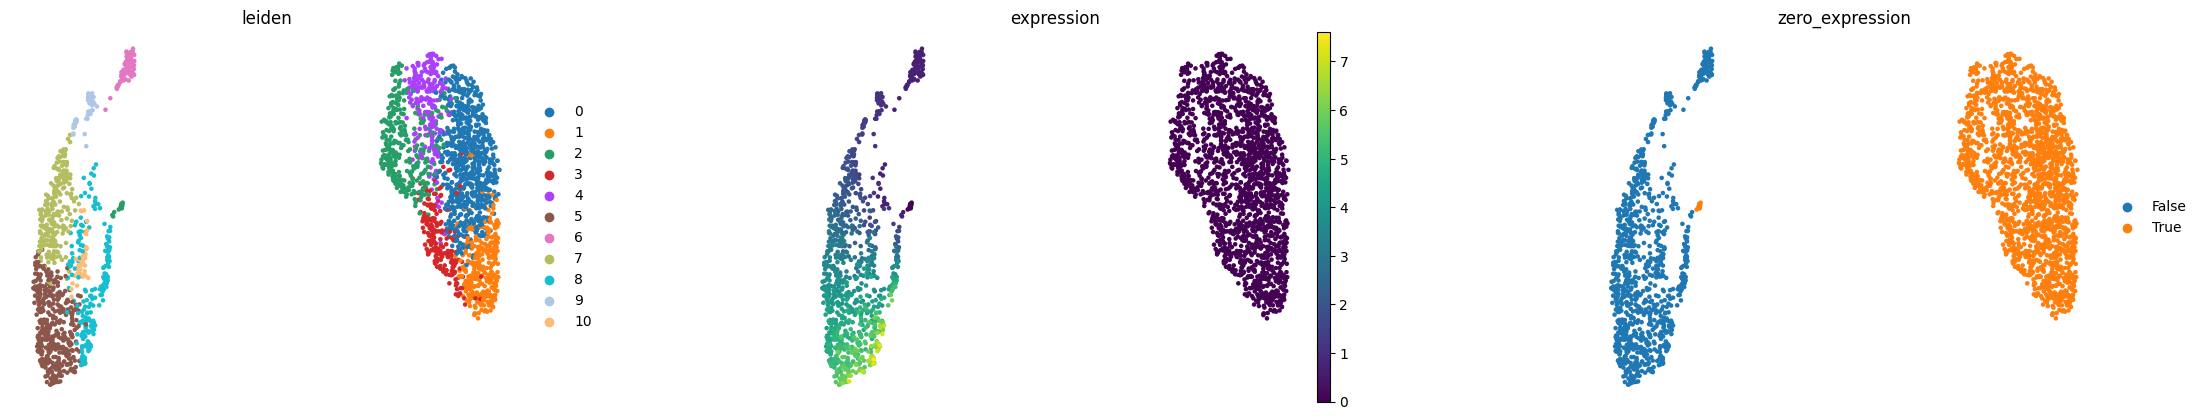

In [35]:
sc.pl.umap(
    gemb_da,
    color=["leiden", "expression", "zero_expression"],
    frameon=False,
    wspace=0.4,
)

In [43]:
for gs in [
    "KEGG_2021_Human",
    "GO_Molecular_Function_2025",
    "WikiPathways_2024_Human",
    "GO_Cellular_Component_2025",
]:
    elems = 0
    for cluster in gemb_da.obs["leiden"].cat.categories:

        pre_res = gp.enrich(
            gene_list=gemb_da.obs.symbol[
                gemb_da.obs["leiden"] == cluster
            ].tolist(),  # or rnk = rnk,
            gene_sets=gs,
            background=gemb_da.obs.symbol.tolist(),  # or "hsapiens_gene_ensembl", or int, or text file  or a list of genes
            outdir=None,
            verbose=True,
        )

        elems += len(pre_res.res2d[pre_res.res2d["Adjusted P-value"] < 0.05])
    print(gs, elems)

2026-05-05 16:53:18,492 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:19,486 [INFO] Done.
2026-05-05 16:53:19,981 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:20,896 [INFO] Done.
2026-05-05 16:53:21,479 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:22,475 [INFO] Done.
2026-05-05 16:53:22,974 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:23,889 [INFO] Done.
2026-05-05 16:53:24,390 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:25,301 [INFO] Done.
2026-05-05 16:53:25,806 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:26,720 [INFO] Done.
2026-05-05 16:53:27,219 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:28,126 [INFO] Done.
2026-05-05 16:53:28,624 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:29,534 [INFO] Done.
2026-05-05 16:53:30,031 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:30,941 [INFO] Done.
2026-05-05 16:53:31,437 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:32,347 [INFO] Done.
2026-05-05 16:53:32,843 [INFO] Run: KEGG_2021_Human
2026-05-05 16:53:33,673 [INFO] Done.


KEGG_2021_Human 64


2026-05-05 16:53:34,168 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:35,167 [INFO] Done.
2026-05-05 16:53:35,667 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:36,658 [INFO] Done.
2026-05-05 16:53:37,158 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:38,150 [INFO] Done.
2026-05-05 16:53:38,646 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:39,636 [INFO] Done.
2026-05-05 16:53:40,134 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:41,122 [INFO] Done.
2026-05-05 16:53:41,616 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:42,610 [INFO] Done.
2026-05-05 16:53:43,108 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:44,021 [INFO] Done.
2026-05-05 16:53:44,523 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:45,509 [INFO] Done.
2026-05-05 16:53:46,009 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:46,918 [INFO] Done.
2026-05-05 16:53:47,415 [INFO] Run: GO_Molecular_Function_2025
2026-05-05 16:53:48,324 [INFO] Done.


GO_Molecular_Function_2025 19


2026-05-05 16:53:50,146 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:51,143 [INFO] Done.
2026-05-05 16:53:51,640 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:52,632 [INFO] Done.
2026-05-05 16:53:53,127 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:54,160 [INFO] Done.
2026-05-05 16:53:54,656 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:55,645 [INFO] Done.
2026-05-05 16:53:56,144 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:57,133 [INFO] Done.
2026-05-05 16:53:57,640 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:53:58,644 [INFO] Done.
2026-05-05 16:53:59,145 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:54:00,057 [INFO] Done.
2026-05-05 16:54:00,555 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:54:01,557 [INFO] Done.
2026-05-05 16:54:02,052 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:54:03,055 [INFO] Done.
2026-05-05 16:54:03,552 [INFO] Run: WikiPathways_2024_Human
2026-05-05 16:54:04,461 [INFO] Done.
2026-05-05 16:54:04,958 [INFO]

WikiPathways_2024_Human 50


2026-05-05 16:54:06,296 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:07,295 [INFO] Done.
2026-05-05 16:54:07,797 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:08,720 [INFO] Done.
2026-05-05 16:54:09,222 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:10,214 [INFO] Done.
2026-05-05 16:54:10,712 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:11,622 [INFO] Done.
2026-05-05 16:54:12,118 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:13,027 [INFO] Done.
2026-05-05 16:54:13,524 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:14,511 [INFO] Done.
2026-05-05 16:54:15,010 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:15,922 [INFO] Done.
2026-05-05 16:54:16,423 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:17,335 [INFO] Done.
2026-05-05 16:54:17,835 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:18,748 [INFO] Done.
2026-05-05 16:54:19,248 [INFO] Run: GO_Cellular_Component_2025
2026-05-05 16:54:20,160 [INFO] Done.


GO_Cellular_Component_2025 46


... storing 'biotype' as categorical
... storing 'organism' as categorical


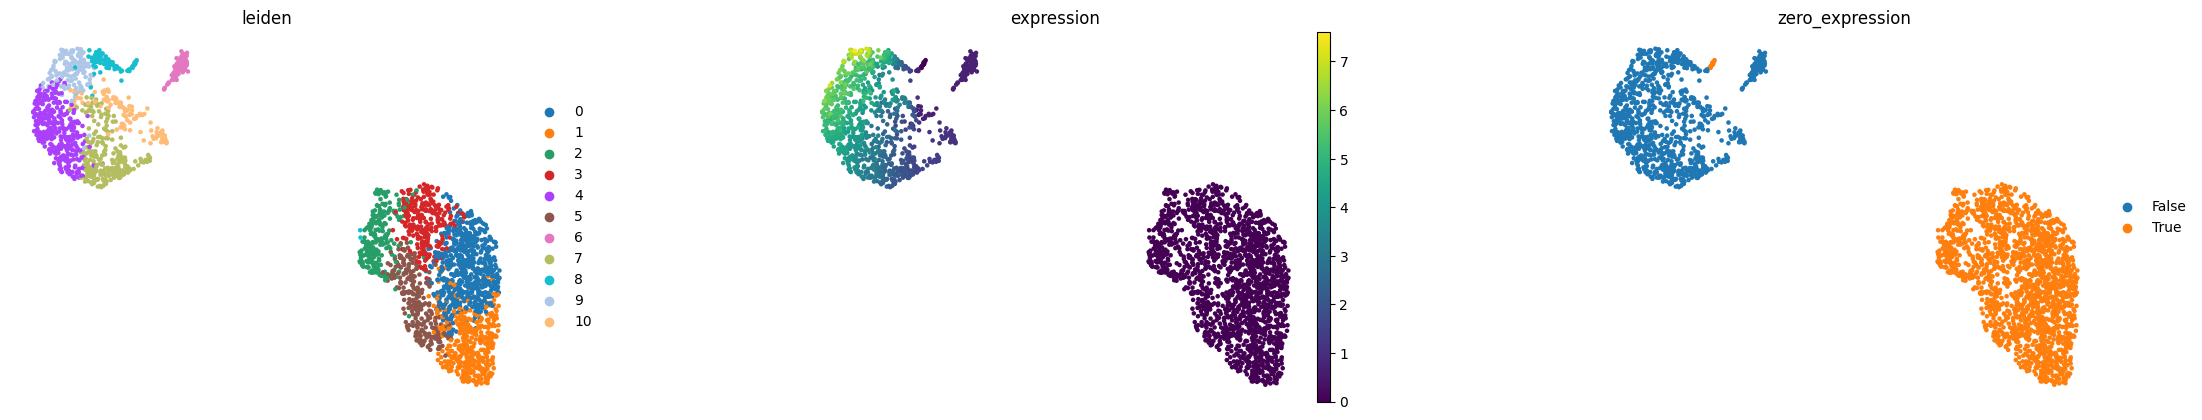

In [73]:
sc.pl.umap(
    gemb_da,
    color=["leiden", "expression", "zero_expression"],
    frameon=False,
    wspace=0.4,
)

In [ ]:
# lots of PPI hub and chromosome location, mircro<RNA, TF chip-seq 2 GO MF, 1 GO CC Nucleus

In [74]:
for gs in [
    "KEGG_2021_Human",
    "GO_Molecular_Function_2025",
    "WikiPathways_2024_Human",
    "GO_Cellular_Component_2025",
]:
    elems = 0
    for cluster in gemb_da.obs["leiden"].cat.categories:

        pre_res = gp.enrich(
            gene_list=gemb_da.obs.symbol[
                gemb_da.obs["leiden"] == cluster
            ].tolist(),  # or rnk = rnk,
            gene_sets=gs,
            background=gemb_da.obs.symbol.tolist(),  # or "hsapiens_gene_ensembl", or int, or text file  or a list of genes
            outdir=None,
            verbose=True,
        )

        elems += len(pre_res.res2d[pre_res.res2d["Adjusted P-value"] < 0.05])
    print(gs, elems)

2025-11-02 16:54:45,172 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:46,279 [INFO] Done.
2025-11-02 16:54:46,897 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:48,052 [INFO] Done.
2025-11-02 16:54:48,581 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:49,641 [INFO] Done.
2025-11-02 16:54:50,208 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:51,273 [INFO] Done.
2025-11-02 16:54:51,839 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:52,897 [INFO] Done.
2025-11-02 16:54:53,451 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:54,506 [INFO] Done.
2025-11-02 16:54:55,037 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:56,086 [INFO] Done.
2025-11-02 16:54:56,633 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:57,686 [INFO] Done.
2025-11-02 16:54:58,234 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:54:59,203 [INFO] Done.
2025-11-02 16:54:59,753 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:55:00,812 [INFO] Done.
2025-11-02 16:55:01,356 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:55:02,404 [INFO] Done.


KEGG_2021_Human 85


2025-11-02 16:55:02,964 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:04,114 [INFO] Done.
2025-11-02 16:55:04,647 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:05,783 [INFO] Done.
2025-11-02 16:55:06,359 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:07,463 [INFO] Done.
2025-11-02 16:55:08,016 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:09,172 [INFO] Done.
2025-11-02 16:55:09,744 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:10,885 [INFO] Done.
2025-11-02 16:55:11,439 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:12,570 [INFO] Done.
2025-11-02 16:55:13,147 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:14,195 [INFO] Done.
2025-11-02 16:55:14,731 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:15,843 [INFO] Done.
2025-11-02 16:55:16,398 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:17,457 [INFO] Done.
2025-11-02 16:55:18,020 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 16:55:19,054 [IN

GO_Molecular_Function_2025 24


2025-11-02 16:55:21,231 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:22,456 [INFO] Done.
2025-11-02 16:55:23,027 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:24,154 [INFO] Done.
2025-11-02 16:55:24,725 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:25,843 [INFO] Done.
2025-11-02 16:55:26,402 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:27,554 [INFO] Done.
2025-11-02 16:55:28,125 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:29,240 [INFO] Done.
2025-11-02 16:55:29,798 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:30,929 [INFO] Done.
2025-11-02 16:55:31,498 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:32,547 [INFO] Done.
2025-11-02 16:55:33,102 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:34,239 [INFO] Done.
2025-11-02 16:55:34,811 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:35,838 [INFO] Done.
2025-11-02 16:55:36,369 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 16:55:37,500 [INFO] Done.
2025-11-02 16:55:38,

WikiPathways_2024_Human 68


2025-11-02 16:55:39,663 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:40,808 [INFO] Done.
2025-11-02 16:55:41,364 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:42,458 [INFO] Done.
2025-11-02 16:55:43,021 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:44,072 [INFO] Done.
2025-11-02 16:55:44,626 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:45,645 [INFO] Done.
2025-11-02 16:55:46,196 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:47,320 [INFO] Done.
2025-11-02 16:55:47,878 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:48,904 [INFO] Done.
2025-11-02 16:55:49,456 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:50,494 [INFO] Done.
2025-11-02 16:55:51,050 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:52,103 [INFO] Done.
2025-11-02 16:55:52,667 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:53,692 [INFO] Done.
2025-11-02 16:55:54,264 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 16:55:55,303 [IN

GO_Cellular_Component_2025 45


# second model without XPressor (here we use the scPRINT-1 package and model)


In [ ]:
# install the scprint1 package on a new env
! source scprint1/bin/activate
# restart the notebook

In [1]:
from scprint import scPrint
from scdataloader import Preprocessor
from scdataloader.utils import load_genes
import gseapy as gp
from huggingface_hub import hf_hub_download

import os
import sys

import numpy as np
import pandas as pd
import scanpy as sc
import urllib.request

%load_ext autoreload
%autoreload 2

import torch

→ connected lamindb: jkobject/scprint2


In [ ]:
import torch
from anndata import AnnData
from scdataloader import Collator
from scdataloader.data import SimpleAnnDataset
from simpler_flash import FlashTransformer
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader


class GeneEmbeddingExtractor_v1:
    def __init__(
        self,
        genelist: list[str],
        batch_size: int = 64,
        num_workers: int = 8,
        save_every: int = 4_000,
        average: bool = False,
        save_dir: str = None,
        use_knn: bool = False,
    ):
        """
        Args:
            genelist (list[str]): List of genes to restrict to.
            batch_size (int): Batch size for the DataLoader. Defaults to 64.
            num_workers (int): Number of workers for DataLoader. Defaults to 8.
            save_every (int): Save embeddings every `save_every` batches. Defaults to 4000.
            average (bool): Whether to average embeddings across all cells. Defaults to False.
            save_dir (str): Directory to save embeddings. If None, embeddings are not saved. Defaults to None.
            use_knn (bool): Whether to use k-nearest neighbors information. Defaults to False.

        """
        self.genelist = genelist
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.save_every = save_every
        self.average = average
        self.save_dir = save_dir
        self.use_knn = use_knn

    def __call__(self, model, adata):
        model.eval()
        model.pred_log_adata = False
        model.predict_mode = "none"

        # Determine which genes to use
        prevl = len(self.genelist)
        gene_list = [g for g in self.genelist if g in model.genes]
        print(
            "Using {:.2f}% of the genes in the gene list".format(
                len(self.genelist) * 100 / prevl
            )
        )
        if len(gene_list) == 0:
            raise ValueError("No overlap between provided gene_list and model.genes")

        # Set up dataset and dataloader
        # If needed, ensure adata.obs contains 'organism_ontology_term_id' or adapt Collator arguments
        if "organism_ontology_term_id" not in adata.obs:
            # Assign a default organism if needed
            adata.obs["organism_ontology_term_id"] = (
                "NCBITaxon:9606"  # or your relevant organism ID
            )

        adataset = SimpleAnnDataset(adata, obs_to_output=["organism_ontology_term_id"])
        col = Collator(
            organisms=model.organisms,
            valid_genes=model.genes,
            max_len=0,
            how="some",
            genelist=gene_list,
            n_bins=model.n_input_bins if model.expr_emb_style == "binned" else 0,
        )
        dataloader = DataLoader(
            adataset,
            collate_fn=col,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            shuffle=False,
        )

        all_embeddings = []
        expr = []
        model.on_predict_epoch_start()
        count = 0
        full_embeddings = None
        # Use float32 to ensure LayerNorm compatibility (float16 not supported on all GPUs)
        dtype = torch.float32
        # Use autocast to ensure half precision if required by the model
        with (
            torch.no_grad(),
            torch.autocast(device_type=model.device.type, dtype=dtype),
        ):
            for batch in dataloader:
                gene_pos, expression, depth = (
                    batch["genes"].to(model.device),
                    batch["x"].to(model.device),
                    batch["depth"].to(model.device),
                )

                # Run encode_only to get transformer outputs
                output = model(
                    gene_pos=gene_pos,
                    expression=expression,
                    req_depth=depth,
                    depth_mult=expression.sum(1),
                    get_gene_emb=True,
                )
                # transformer_output shape: (B, cell_embs_count + num_genes, d_model)
                # Extract gene embeddings:
                gene_embeddings = output["gene_embedding"]
                # shape: (B, num_genes, d_model)
                if self.average:
                    if full_embeddings is None:
                        # Average the gene embeddings across the batch
                        full_embeddings = gene_embeddings.mean(dim=0, keepdim=True)
                    else:
                        full_embeddings += gene_embeddings.mean(dim=0, keepdim=True)
                    count += 1
                else:
                    all_embeddings.append(gene_embeddings.cpu().numpy())
                expr.append(batch["x"].numpy())
                if (
                    len(all_embeddings) * self.batch_size
                ) >= self.save_every and not self.average:
                    # Save embeddings to disk or process them as needed
                    ad = AnnData(
                        X=np.concatenate(expr, axis=0),
                        var=pd.DataFrame(index=gene_list),
                        varp=np.concatenate(all_embeddings, axis=0),
                    )
                    if self.save_dir is None:
                        print(
                            "reached max len, need to save embeddings but did not specify save_dir"
                        )
                        print("using default save_dir: ./data/")
                        self.save_dir = "./data/"
                    if not os.path.exists(self.save_dir):
                        os.makedirs(self.save_dir)
                    ad.write_h5ad(
                        os.path.join(self.save_dir, f"embeddings_{count}.h5ad")
                    )
                    count += 1
                    del ad
                    all_embeddings = []
                    expr = []
                del output
                torch.cuda.empty_cache()
        ad = AnnData(
            X=np.concatenate(expr, axis=0),
            var=pd.DataFrame(index=gene_list),
            uns=(
                {"all_embeddings": np.concatenate(all_embeddings, axis=0)}
                if not self.average
                else None
            ),
            varm=full_embeddings.cpu().numpy() / count if self.average else None,
        )
        if self.save_dir is not None:
            ad.write_h5ad(os.path.join(self.save_dir, f"embeddings_{count}.h5ad"))
            print("save {} embeddings files under {}".format(count, self.save_dir))
        return ad

In [ ]:
model_checkpoint_file = hf_hub_download(
    repo_id="jkobject/scPRINT", filename=f"large-v1.ckpt",
)
# model_checkpoint_file = ../data/
# LOC2 = "/pasteur/appa/scratch/jkalfon/models/"  # "../../../"
# model_checkpoint_file = LOC2 + "models/z3abxa21-nogen.ckpt"
# model_checkpoint_file = "../../../psqzicou.ckpt"
# ogvvg2z7-v1
# w937u4o1

In [ ]:
model2 = scPrint.load_from_checkpoint(
    model_checkpoint_file,
    precpt_gene_emb=None,
    transformer="flash" if torch.cuda.is_available() else "normal"
)
if torch.cuda.is_available():
    model2 = model2.to("cuda")

RuntimeError caught: scPrint is not attached to a `Trainer`.


In [ ]:
if not torch.cuda.is_available():
    model2 = model2.to(torch.float32)

model2 = model2.to("cuda" if torch.cuda.is_available() else "cpu")
missing = set(model2.genes) - set(load_genes(model2.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )
    model2._rm_genes(missing)

In [ ]:
LOC = "/pasteur/appa/scratch/jkalfon/data/spcrint_data/"  # "../..data/"  #

adata = sc.read(
    LOC + "temp/glio_smart_highdepth" + ".h5ad",
    backup_url="https://datasets.cellxgene.cziscience.com/6ec440b4-542a-4022-ac01-56f812e25593.h5ad",
)

max_len = 4000 if adata.X.sum(1).mean() < 10_000 else 8000
preprocessor = Preprocessor(
    force_preprocess=True,
    skip_validate=True,
    # drop_non_primary=False,
    do_postp=True,
)
print("")
print(adata.X.sum(1).mean())
adata = preprocessor(adata)


388362.5
Dropping layers:  KeysView(Layers with keys: )
checking raw counts
removed 0 non primary cells, 3589 renamining
filtered out 22 cells, 3567 renamining
Removed 0 genes not known to the ontology
Removed 0 duplicate genes
Added 47967 genes in the ontology but not present in the dataset
starting QC
Seeing 71 outliers (1.99% of total dataset):
normalize
starting PCA
done
AnnData object with n_obs × n_vars = 3567 × 70116
    obs: 'Sample.type', 'Selection', 'Location', 'Sample.name', 'Total_reads', 'Unique_reads', 'Unique_reads_percent', 'Splice_sites_total', 'Splice_sites_Annotated', 'Splice_sites_GT.AG', 'Splice_sites_GC.AG', 'Splice_sites_AT.AC', 'Splice_sites_non_canonical', 'Multimapping_reads_percent', 'Unmapped_mismatch', 'Unmapped_short', 'Unmapped_other', 'ERCC_reads', 'Non_ERCC_reads', 'ERCC_to_non_ERCC', 'Genes_detected', 'housekeeping_cluster', 'Cluster_2d', 'Cluster_2d_color', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_o

In [7]:
cell_type = "vascular lymphangioblast"
extractor = GeneEmbeddingExtractor_v1(
    genelist=adata.var.index[
        np.array(
            (adata[adata.obs.cell_type == cell_type].X > 0).sum(0)
            > (adata.obs.cell_type.value_counts()[cell_type] * 0.3)
        )[0]
    ].tolist(),
    batch_size=16,
    num_workers=8,
    average=False,
)

In [8]:
gemb_da_2 = extractor(model2, adata[adata.obs.cell_type == cell_type, :][:2])

Using 100.00% of the genes in the gene list


/pasteur/appa/homes/jkalfon/scPRINT/scprint1/lib64/python3.12/site-packages/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)
/local/scratch/tmp/tmp_l7o6ao6/main.c:4:10: fatal error: Python.h: No such file or directory
 #include <Python.h>
          ^~~~~~~~~~
compilation terminated.


CalledProcessError: Command '['/usr/bin/gcc', '/local/scratch/tmp/tmp_l7o6ao6/main.c', '-O3', '-I/pasteur/appa/homes/jkalfon/scPRINT/scprint1/lib64/python3.12/site-packages/triton/common/../third_party/cuda/include', '-I/usr/include/python3.12', '-I/local/scratch/tmp/tmp_l7o6ao6', '-shared', '-fPIC', '-lcuda', '-o', '/local/scratch/tmp/tmp_l7o6ao6/_fwd_kernel.cpython-312-x86_64-linux-gnu.so', '-L/lib64', '-L/lib64']' returned non-zero exit status 1.

In [ ]:
gemb_da_2.varm["gene_embeddings"] = gemb_da_2.uns["all_embeddings"].mean(0)

gemb_da_2 = gemb_da_2.T

In [78]:
gemb_da_2.obsm["gene_pca"] = sc.pp.pca(
    gemb_da_2.obsm["gene_embeddings"], n_comps=30, use_highly_variable=False
)

sc.pp.neighbors(
    gemb_da_2,
    use_rep="gene_pca",  # can be a plain NumPy / sparse array
    n_neighbors=15,
    key_added="gene_neighbors",  # keeps it separate from the cell graph
)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [79]:
sc.tl.umap(
    gemb_da_2,
    neighbors_key="gene_neighbors",  # tells Scanpy which graph to use
    init_pos="spectral",
    random_state=0,
    min_dist=0.3,
)

In [80]:
genes = load_genes(["NCBITaxon:9606"])

In [86]:
gemb_da_2.obs = genes.loc[gemb_da_2.obs.index]

In [87]:
gemb_da_2.obs["expression"] = np.log(1 + gemb_da_2.X[:, 0])
gemb_da_2.obs["zero_expression"] = gemb_da_2.X[:, 0] == 0

In [ ]:
sc.tl.leiden(
    gemb_da_2,
    neighbors_key="gene_neighbors",
    resolution=0.5, # to get the same number of clusters as model 1
    key_added="leiden",
    flavor="igraph",
    random_state=42,
)  # use weights to get more clusters

In [ ]:
sc.pl.umap(
    gemb_da_2,
    color=["leiden", "expression", "zero_expression"],
    frameon=False,
    wspace=0.4,
)  # mean of all

NameError: name 'gemb_da_2' is not defined

0 go MF, 0 CC, 0 TF chip seq...


In [39]:
len(gemb_da.obs["leiden"].cat.categories)

11

In [ ]:
for gs in [
    "KEGG_2021_Human",
    "GO_Molecular_Function_2025",
    "WikiPathways_2024_Human",
    "GO_Cellular_Component_2025",
]:
    elems = 0
    for cluster in gemb_da_2.obs["leiden"].cat.categories:

        pre_res = gp.enrich(
            gene_list=gemb_da_2.obs.symbol[
                gemb_da_2.obs["leiden"] == cluster
            ].tolist(),  # or rnk = rnk,
            gene_sets=gs,
            background=gemb_da_2.obs.symbol.tolist(),  # or "hsapiens_gene_ensembl", or int, or text file  or a list of genes
            outdir=None,
            verbose=True,
        )

        elems += len(pre_res.res2d[pre_res.res2d["Adjusted P-value"] < 0.05])
    print(gs, elems / len(gemb_da_2.obs["leiden"].cat.categories))

2025-11-02 16:59:50,206 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:51,189 [INFO] Done.
2025-11-02 16:59:51,837 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:52,872 [INFO] Done.
2025-11-02 16:59:53,432 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:54,443 [INFO] Done.
2025-11-02 16:59:54,990 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:56,120 [INFO] Done.
2025-11-02 16:59:56,684 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:57,737 [INFO] Done.
2025-11-02 16:59:58,306 [INFO] Run: KEGG_2021_Human 
2025-11-02 16:59:59,367 [INFO] Done.
2025-11-02 16:59:59,940 [INFO] Run: KEGG_2021_Human 
2025-11-02 17:00:00,973 [INFO] Done.
2025-11-02 17:00:01,529 [INFO] Run: KEGG_2021_Human 
2025-11-02 17:00:02,694 [INFO] Done.
2025-11-02 17:00:03,278 [INFO] Run: KEGG_2021_Human 
2025-11-02 17:00:04,650 [INFO] Done.
2025-11-02 17:00:05,199 [INFO] Run: KEGG_2021_Human 
2025-11-02 17:00:06,239 [INFO] Done.
2025-11-02 17:00:06,793 [INFO] Run: KEGG_2021_Human 
2025-11-02 17:00:07,844 [INFO] Done.
2025-11-02

KEGG_2021_Human 19


2025-11-02 17:00:14,786 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:15,731 [INFO] Done.
2025-11-02 17:00:16,289 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:17,416 [INFO] Done.
2025-11-02 17:00:17,952 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:18,981 [INFO] Done.
2025-11-02 17:00:19,528 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:20,644 [INFO] Done.
2025-11-02 17:00:21,204 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:22,250 [INFO] Done.
2025-11-02 17:00:22,794 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:23,922 [INFO] Done.
2025-11-02 17:00:24,490 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:25,627 [INFO] Done.
2025-11-02 17:00:26,196 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:27,244 [INFO] Done.
2025-11-02 17:00:27,782 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:28,928 [INFO] Done.
2025-11-02 17:00:29,470 [INFO] Run: GO_Molecular_Function_2025 
2025-11-02 17:00:30,585 [IN

GO_Molecular_Function_2025 4


2025-11-02 17:00:39,284 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:40,302 [INFO] Done.
2025-11-02 17:00:40,855 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:41,979 [INFO] Done.
2025-11-02 17:00:42,537 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:43,633 [INFO] Done.
2025-11-02 17:00:44,200 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:45,301 [INFO] Done.
2025-11-02 17:00:45,832 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:46,955 [INFO] Done.
2025-11-02 17:00:47,511 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:48,617 [INFO] Done.
2025-11-02 17:00:49,148 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:50,240 [INFO] Done.
2025-11-02 17:00:50,771 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:51,906 [INFO] Done.
2025-11-02 17:00:52,434 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:53,560 [INFO] Done.
2025-11-02 17:00:54,115 [INFO] Run: WikiPathways_2024_Human 
2025-11-02 17:00:55,257 [INFO] Done.
2025-11-02 17:00:55,

WikiPathways_2024_Human 8


2025-11-02 17:01:04,023 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:05,070 [INFO] Done.
2025-11-02 17:01:05,635 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:06,700 [INFO] Done.
2025-11-02 17:01:07,259 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:08,318 [INFO] Done.
2025-11-02 17:01:08,867 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:09,997 [INFO] Done.
2025-11-02 17:01:10,562 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:11,613 [INFO] Done.
2025-11-02 17:01:12,171 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:13,300 [INFO] Done.
2025-11-02 17:01:13,862 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:14,896 [INFO] Done.
2025-11-02 17:01:15,448 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:16,485 [INFO] Done.
2025-11-02 17:01:17,049 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:18,193 [INFO] Done.
2025-11-02 17:01:18,737 [INFO] Run: GO_Cellular_Component_2025 
2025-11-02 17:01:19,775 [IN

GO_Cellular_Component_2025 17


In [42]:
from scipy.stats import ttest_ind, ttest_rel
import pandas as pd

# 2784, 2784
cols = ["xpressor_generator", "no_xpressor", "no_xpressor_large"]
data = {
    "GO_Cellular_Component_2025": [85, 20, 58],
    "WikiPathways_2024_Human": [24, 23, 3],
    "GO_Molecular_Function_2025": [68, 2, 47],
    "KEGG_2021_Human": [45, 23, 44],
}

# 87, 30, 61, 60

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data, index=cols).T
withelem = "no_xpressor_large"

# Paired t-test (since comparing same gene sets)
t_stat, p_value = ttest_rel(
    (df["xpressor_generator"]).astype(int), (df[withelem]).astype(int)
)

print(f"Paired t-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Independent t-test (if you prefer)
t_stat_ind, p_value_ind = ttest_ind(df["xpressor_generator"], df[withelem])

print(f"\nIndependent t-test results:")
print(f"t-statistic: {t_stat_ind:.4f}")
print(f"p-value: {p_value_ind:.4f}")

# Summary statistics
print(f"\nMean enrichments:")
print(
    f"Xpressor generator: {df['xpressor_generator'].mean():.2f} ± {df['xpressor_generator'].std():.2f}"
)
print(f"No xpressor: {df[withelem].mean():.2f} ± {df[withelem].std():.2f}")

Paired t-test results:
t-statistic: 3.0816
p-value: 0.0541

Independent t-test results:
t-statistic: 0.9744
p-value: 0.3675

Mean enrichments:
Xpressor generator: 55.50 ± 26.64
No xpressor: 38.00 ± 24.10


In [44]:
LOC2 = "/pasteur/appa/scratch/jkalfon/models/"  # "../../../"
# w937u4o1 medium (other_ckpts)
# small-v2
ckpt_path = os.path.join(LOC2, "w937u4o1.ckpt")
if not os.path.exists(ckpt_path):
    url = "https://huggingface.co/jkobject/scPRINT/resolve/main/other_ckpts/w937u4o1.ckpt"
    urllib.request.urlretrieve(url, ckpt_path)

model = scPRINT2.load_from_checkpoint(
    ckpt_path, precpt_gene_emb=None, gene_pos_file=None
)

Gene position encoding has changed in the dataloader compared to last time, trying to revert
converting a gene list-based model


/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


FYI: scPRINT2 is not attached to a `Trainer`.


## old one


... storing 'biotype' as categorical
... storing 'organism' as categorical


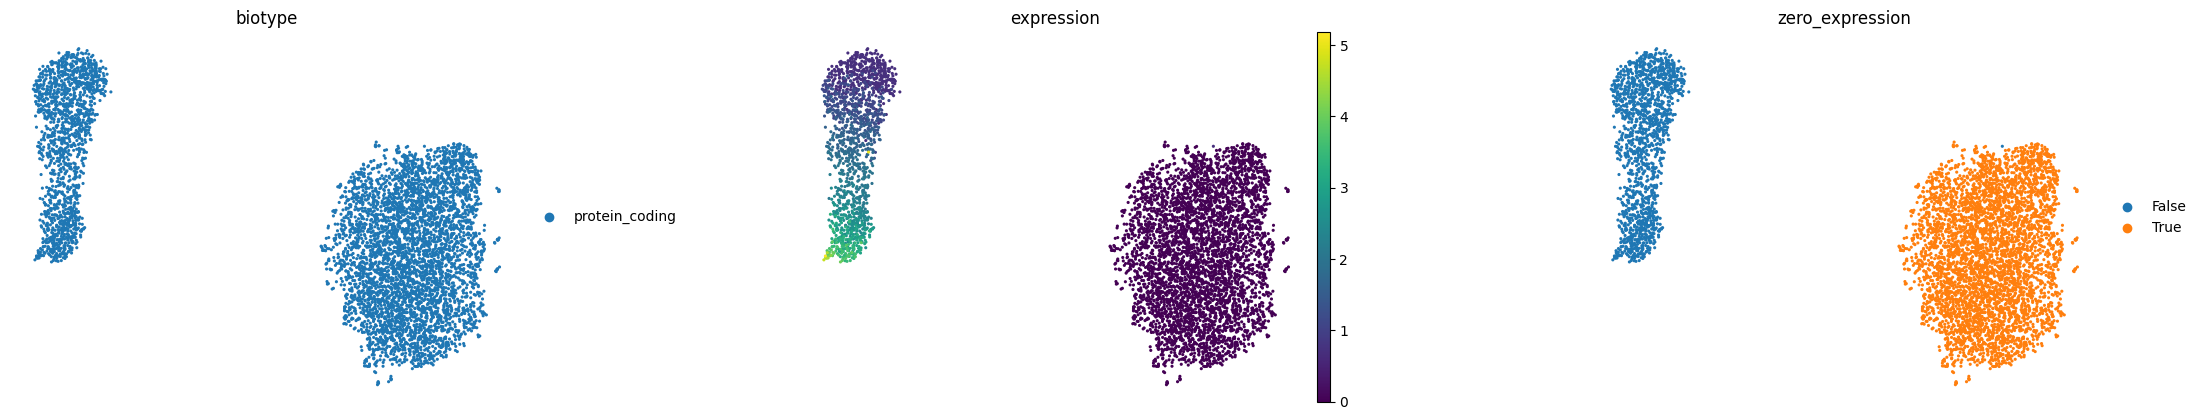

In [ ]:
sc.pl.umap(
    gemb_da_2,
    color=["biotype", "expression", "zero_expression"],
    frameon=False,
    wspace=0.4,
)